# Auto Insurance Claim Frequency — Poisson GLM

This notebook develops and evaluates a Poisson generalized linear model (GLM) for auto insurance claim frequency while accounting for multiple policy and risk characteristics simultaneously.

In [278]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("freMTPL2freq.csv")

In [279]:
df.shape


(678013, 12)

In [280]:
df.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region'],
      dtype='str')

To confirm that all exposure values are positive:

In [281]:
df["Exposure"].min() 

np.float64(0.00273224)

Creating driver-age, BonusMalus, and vehicle-age categories:

In [282]:
age_bins = [17, 24, 34, 44, 54, 64, float("inf")]

age_labels = [
    "18 to 24",
    "25 to 34",
    "35 to 44",
    "45 to 54",
    "55 to 64",
    "65+"
]

df["AgeCategory"] = pd.cut(
    df["DrivAge"],
    bins=age_bins,
    labels=age_labels
)

bonusmalus_bins=[49,50,75,100,float("inf")]
bonusmalus_labels = [
    "50",
    "51 to 75",
    "76 to 100",
    "101+"
]

df["BonusMalusCategory"] = pd.cut(
    df["BonusMalus"],
    bins=bonusmalus_bins,
    labels=bonusmalus_labels
)

vehage_bins=[-1,10,20,float("inf")]
vehage_labels = [
    "0 to 10",
    "11 to 20",
    "21+"
]

df["VehAgeCategory"] = pd.cut(
    df["VehAge"],
    bins=vehage_bins,
    labels=vehage_labels
)


To confirm that the newly created categories contain no missing values:

In [283]:
print(
    df["AgeCategory"].isna().sum(),
    df["BonusMalusCategory"].isna().sum(),
    df["VehAgeCategory"].isna().sum()
    )

0 0 0


### Poisson Claim-Frequency Model

A Poisson generalized linear model with a log link is used to model claim counts. Policy exposure is incorporated so that differences in time at risk are properly accounted for.

The model includes driver age, BonusMalus, vehicle age, vehicle power, fuel type, vehicle brand, and geographic area. Categorical predictors are represented using indicator variables, with one category serving as the reference level for each factor.

Population density and region are not included in this initial specification because the exploratory analysis showed strong overlap between geographic variables, particularly Area and Density.

In [284]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
formula="ClaimNb ~ C(AgeCategory)+ C(BonusMalusCategory) + C(VehAgeCategory) + VehPower + C(VehGas) + C(VehBrand) + C(Area)"
model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Poisson(),
    exposure=df["Exposure"]
)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677985
Model Family:                 Poisson   Df Model:                           27
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4364e+05
Date:                Sat, 05 Sep 2026   Deviance:                   2.1795e+05
Time:                        11:57:28   Pearson chi2:                 1.83e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.009585
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.6701      0.035    -76.463      0.000      -2.739      -2.602
C(AgeCategory)[T.25 to 34]            -0.3914      0.025    -15.424      0.000      -0.441      -0.342
C(AgeCategory)[T.35 to 44]            -0.1535      0.026     -5.896      0.000      -0.205      -0.102
C(AgeCategory)[T.45 to 54]             0.0911      0.026      3.456      0.001       0.039       0.143
C(AgeCategory)[T.55 to 64]            -0.0507      0.028     -1.793      0.073      -0.106       0.005
C(AgeCategory)[T.65+]                  0.0397      0.029      1.375      0.169      -0.017       0.096
C(BonusMalusCategory)[T.51 to 75]      0.4780      0.014     34.696      0.000       0.451       0.505
C(BonusMalusCategory)[T.76 to 100]     0.8106      0.017     47.602      0.000       0.777       0.844
C(BonusMalusCategory)[T.101+]          1.6434      0.030     54.430      0.000       1.584       1.703
C(VehAgeCategory)[T.11 to 20]         -0.2683      0.013    -20.298      0.000      -0.294      -0.242
C(VehAgeCategory)[T.21+]              -0.6009      0.061     -9.874      0.000      -0.720      -0.482
C(VehGas)[T.Regular]                   0.0433      0.011      3.957      0.000       0.022       0.065
C(VehBrand)[T.B10]                     0.0042      0.037      0.114      0.910      -0.068       0.076
C(VehBrand)[T.B11]                     0.0973      0.040      2.460      0.014       0.020       0.175
C(VehBrand)[T.B12]                     0.2629      0.016     16.515      0.000       0.232       0.294
C(VehBrand)[T.B13]                     0.0332      0.041      0.811      0.417      -0.047       0.113
C(VehBrand)[T.B14]                    -0.1741      0.078     -2.220      0.026      -0.328      -0.020
C(VehBrand)[T.B2]                     -0.0068      0.015     -0.446      0.655      -0.037       0.023
C(VehBrand)[T.B3]                      0.0132      0.022      0.604      0.546      -0.030       0.056
C(VehBrand)[T.B4]                     -0.0335      0.030     -1.126      0.260      -0.092       0.025
C(VehBrand)[T.B5]                      0.0591      0.025      2.388      0.017       0.011       0.108
C(VehBrand)[T.B6]                     -0.0428      0.028     -1.510      0.131      -0.098       0.013
C(Area)[T.B]                           0.0452      0.021      2.105      0.035       0.003       0.087
C(Area)[T.C]                           0.0816      0.017      4.700      0.000       0.048       0.116
C(Area)[T.D]                           0.1649      0.018      9.169      0.000       0.130       0.200
C(Area)[T.E]                           0.2139      0.018     11.584      0.000       0.178       0.250
C(Area)[T.F]                           0.2246      0.034      6.690      0.000       0.159      

### Reference Categories

Model relativities are interpreted relative to the following reference categories:

- Driver age: 18–24
- BonusMalus: 50
- Vehicle age: 0–10
- Fuel type: Diesel
- Vehicle brand: B1
- Area: A

For categorical predictors, a relativity above 1 indicates higher modeled claim frequency than the reference category, while a relativity below 1 indicates lower modeled claim frequency, holding the other modeled variables constant.

In [285]:
np.exp(result.params)

Intercept                             0.069242
C(AgeCategory)[T.25 to 34]            0.676127
C(AgeCategory)[T.35 to 44]            0.857682
C(AgeCategory)[T.45 to 54]            1.095379
C(AgeCategory)[T.55 to 64]            0.950598
C(AgeCategory)[T.65+]                 1.040509
C(BonusMalusCategory)[T.51 to 75]     1.612801
C(BonusMalusCategory)[T.76 to 100]    2.249219
C(BonusMalusCategory)[T.101+]         5.172779
C(VehAgeCategory)[T.11 to 20]         0.764672
C(VehAgeCategory)[T.21+]              0.548333
C(VehGas)[T.Regular]                  1.044239
C(VehBrand)[T.B10]                    1.004190
C(VehBrand)[T.B11]                    1.102154
C(VehBrand)[T.B12]                    1.300707
C(VehBrand)[T.B13]                    1.033742
C(VehBrand)[T.B14]                    0.840184
C(VehBrand)[T.B2]                     0.993203
C(VehBrand)[T.B3]                     1.013265
C(VehBrand)[T.B4]                     0.967098
C(VehBrand)[T.B5]                     1.060838
C(VehBrand)[T

In [286]:
model_results = pd.DataFrame({
    "Coefficient": result.params,
    "Relativity": np.exp(result.params),
    "PValue": result.pvalues
})
model_results

,Coefficient,Relativity,PValue
Intercept,-2.670148,0.069242,0.000000e+00
C(AgeCategory)[T.25 to 34],-0.391374,0.676127,1.130735e-53
C(AgeCategory)[T.35 to 44],-0.153522,0.857682,3.733809e-09
C(AgeCategory)[T.45 to 54],0.091101,1.095379,5.491611e-04
C(AgeCategory)[T.55 to 64],-0.050664,0.950598,7.297506e-02
C(AgeCategory)[T.65+],0.039710,1.040509,1.691893e-01
C(BonusMalusCategory)[T.51 to 75],0.477972,1.612801,9.000000e-264
C(BonusMalusCategory)[T.76 to 100],0.810583,2.249219,0.000000e+00
C(BonusMalusCategory)[T.101+],1.643410,5.172779,0.000000e+00
C(VehAgeCategory)[T.11 to 20],-0.268308,0.764672,1.337183e-91


In [287]:
result.pearson_chi2

np.float64(1828000.5404998315)

In [288]:
result.df_resid

np.int64(677985)

In [289]:
dispersion=result.pearson_chi2/result.df_resid
dispersion

np.float64(2.696225639947538)

### Poisson Dispersion Check

The Pearson dispersion statistic is approximately 2.70. Since a value near 1 is expected under the Poisson assumption, this indicates overdispersion in the claim-count data. Therefore, the basic Poisson model may underestimate the variability and uncertainty in the data, and an alternative approach should be considered.

### Addressing Overdispersion

The Poisson GLM exhibited a dispersion statistic of approximately 2.70, indicating that the claim counts are more variable than assumed by the standard Poisson model. To account for this overdispersion while retaining the Poisson mean structure, a Pearson-scaled Poisson model is used to adjust the estimated standard errors and statistical inference.

In [290]:
scaled_result = model.fit(scale="X2")
scaled_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677985
Model Family:                 Poisson   Df Model:                           27
Link Function:                    Log   Scale:                          2.6962
Method:                          IRLS   Log-Likelihood:                -53273.
Date:                Sat, 05 Sep 2026   Deviance:                   2.1795e+05
Time:                        11:57:32   Pearson chi2:                 1.83e+06
No. Iterations:                    10   Pseudo R-squ. (CS):           0.003566
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.6701      0.057    -46.567      0.000      -2.783      -2.558
C(AgeCategory)[T.25 to 34]            -0.3914      0.042     -9.393      0.000      -0.473      -0.310
C(AgeCategory)[T.35 to 44]            -0.1535      0.043     -3.590      0.000      -0.237      -0.070
C(AgeCategory)[T.45 to 54]             0.0911      0.043      2.104      0.035       0.006       0.176
C(AgeCategory)[T.55 to 64]            -0.0507      0.046     -1.092      0.275      -0.142       0.040
C(AgeCategory)[T.65+]                  0.0397      0.047      0.837      0.402      -0.053       0.133
C(BonusMalusCategory)[T.51 to 75]      0.4780      0.023     21.130      0.000       0.434       0.522
C(BonusMalusCategory)[T.76 to 100]     0.8106      0.028     28.990      0.000       0.756       0.865
C(BonusMalusCategory)[T.101+]          1.6434      0.050     33.148      0.000       1.546       1.741
C(VehAgeCategory)[T.11 to 20]         -0.2683      0.022    -12.362      0.000      -0.311      -0.226
C(VehAgeCategory)[T.21+]              -0.6009      0.100     -6.013      0.000      -0.797      -0.405
C(VehGas)[T.Regular]                   0.0433      0.018      2.410      0.016       0.008       0.078
C(VehBrand)[T.B10]                     0.0042      0.060      0.069      0.945      -0.114       0.123
C(VehBrand)[T.B11]                     0.0973      0.065      1.498      0.134      -0.030       0.225
C(VehBrand)[T.B12]                     0.2629      0.026     10.058      0.000       0.212       0.314
C(VehBrand)[T.B13]                     0.0332      0.067      0.494      0.621      -0.098       0.165
C(VehBrand)[T.B14]                    -0.1741      0.129     -1.352      0.176      -0.427       0.078
C(VehBrand)[T.B2]                     -0.0068      0.025     -0.272      0.786      -0.056       0.042
C(VehBrand)[T.B3]                      0.0132      0.036      0.368      0.713      -0.057       0.083
C(VehBrand)[T.B4]                     -0.0335      0.049     -0.686      0.493      -0.129       0.062
C(VehBrand)[T.B5]                      0.0591      0.041      1.454      0.146      -0.021       0.139
C(VehBrand)[T.B6]                     -0.0428      0.047     -0.919      0.358      -0.134       0.048
C(Area)[T.B]                           0.0452      0.035      1.282      0.200      -0.024       0.114
C(Area)[T.C]                           0.0816      0.029      2.862      0.004       0.026       0.138
C(Area)[T.D]                           0.1649      0.030      5.584      0.000       0.107       0.223
C(Area)[T.E]                           0.2139      0.030      7.055      0.000       0.154       0.273
C(Area)[T.F]                           0.2246      0.055      4.074      0.000       0.117      

### Scaled Poisson Model — Key Finding

Applying Pearson scaling increased the estimated standard errors to reflect the observed overdispersion while leaving the model coefficients and relativities essentially unchanged. As a result, several predictors that appeared statistically significant under the standard Poisson model are no longer significant at the 5% level. The scaled Poisson model therefore provides more conservative and appropriate statistical inference for this dataset.

In [291]:
model_scaled_results = pd.DataFrame({
    "Coefficient": scaled_result.params,
    "Relativity": np.exp(scaled_result.params),
    "PValue": scaled_result.pvalues
})
model_scaled_results

,Coefficient,Relativity,PValue
Intercept,-2.670148,0.069242,0.000000e+00
C(AgeCategory)[T.25 to 34],-0.391374,0.676127,5.817602e-21
C(AgeCategory)[T.35 to 44],-0.153522,0.857682,3.301170e-04
C(AgeCategory)[T.45 to 54],0.091101,1.095379,3.533875e-02
C(AgeCategory)[T.55 to 64],-0.050664,0.950598,2.748593e-01
C(AgeCategory)[T.65+],0.039710,1.040509,4.024407e-01
C(BonusMalusCategory)[T.51 to 75],0.477972,1.612801,4.198650e-99
C(BonusMalusCategory)[T.76 to 100],0.810583,2.249219,8.846686e-185
C(BonusMalusCategory)[T.101+],1.643410,5.172779,6.063789e-241
C(VehAgeCategory)[T.11 to 20],-0.268308,0.764672,4.213694e-35


### Final Model Interpretation

After adjusting for overdispersion, BonusMalus remains the strongest and most consistent predictor of claim frequency. Higher BonusMalus categories are associated with substantially higher modeled claim frequency, with the 101+ category having a relativity of approximately 5.17 compared with the reference category of 50.

Driver age, vehicle age, geographic area, fuel type, vehicle brand, and vehicle power also show varying levels of association with claim frequency. Several coefficient estimates that appeared statistically significant under the standard Poisson model are no longer significant at the 5% level after scaling.

Model relativities represent associations after simultaneously accounting for the other included predictors and should not be interpreted as causal effects.

In [292]:
#removing intercept form the previous data

plot_results = model_scaled_results.drop("Intercept")
plot_results.index

Index(['C(AgeCategory)[T.25 to 34]', 'C(AgeCategory)[T.35 to 44]',
       'C(AgeCategory)[T.45 to 54]', 'C(AgeCategory)[T.55 to 64]',
       'C(AgeCategory)[T.65+]', 'C(BonusMalusCategory)[T.51 to 75]',
       'C(BonusMalusCategory)[T.76 to 100]', 'C(BonusMalusCategory)[T.101+]',
       'C(VehAgeCategory)[T.11 to 20]', 'C(VehAgeCategory)[T.21+]',
       'C(VehGas)[T.Regular]', 'C(VehBrand)[T.B10]', 'C(VehBrand)[T.B11]',
       'C(VehBrand)[T.B12]', 'C(VehBrand)[T.B13]', 'C(VehBrand)[T.B14]',
       'C(VehBrand)[T.B2]', 'C(VehBrand)[T.B3]', 'C(VehBrand)[T.B4]',
       'C(VehBrand)[T.B5]', 'C(VehBrand)[T.B6]', 'C(Area)[T.B]',
       'C(Area)[T.C]', 'C(Area)[T.D]', 'C(Area)[T.E]', 'C(Area)[T.F]',
       'VehPower'],
      dtype='str')

In [293]:
#Cleaning the index

clean_labels = (
    plot_results.index
    .str.replace("C(AgeCategory)[T.", "Driver Age: ", regex=False)
    .str.replace("C(BonusMalusCategory)[T.", "BonusMalus: ", regex=False)
    .str.replace("C(VehAgeCategory)[T.", "Vehicle Age: ", regex=False)
    .str.replace("C(VehGas)[T.", "Fuel: ", regex=False)
    .str.replace("C(VehBrand)[T.", "Vehicle Brand: ", regex=False)
    .str.replace("C(Area)[T.", "Area: ", regex=False)
    .str.replace("VehPower","Vehicle Power", regex=False)
    .str.replace("]", "", regex=False)
)
clean_labels

Index(['Driver Age: 25 to 34', 'Driver Age: 35 to 44', 'Driver Age: 45 to 54',
       'Driver Age: 55 to 64', 'Driver Age: 65+', 'BonusMalus: 51 to 75',
       'BonusMalus: 76 to 100', 'BonusMalus: 101+', 'Vehicle Age: 11 to 20',
       'Vehicle Age: 21+', 'Fuel: Regular', 'Vehicle Brand: B10',
       'Vehicle Brand: B11', 'Vehicle Brand: B12', 'Vehicle Brand: B13',
       'Vehicle Brand: B14', 'Vehicle Brand: B2', 'Vehicle Brand: B3',
       'Vehicle Brand: B4', 'Vehicle Brand: B5', 'Vehicle Brand: B6',
       'Area: B', 'Area: C', 'Area: D', 'Area: E', 'Area: F', 'Vehicle Power'],
      dtype='str')

In [294]:
conf_int = scaled_result.conf_int()
conf_int

,0,1
Intercept,-2.782533,-2.557763
C(AgeCategory)[T.25 to 34],-0.473037,-0.309711
C(AgeCategory)[T.35 to 44],-0.237327,-0.069717
C(AgeCategory)[T.45 to 54],0.006255,0.175947
C(AgeCategory)[T.55 to 64],-0.141604,0.040275
C(AgeCategory)[T.65+],-0.053248,0.132668
C(BonusMalusCategory)[T.51 to 75],0.433637,0.522307
C(BonusMalusCategory)[T.76 to 100],0.755780,0.865385
C(BonusMalusCategory)[T.101+],1.546239,1.740581
C(VehAgeCategory)[T.11 to 20],-0.310849,-0.225768


In [295]:
conf_int_exp = np.exp(scaled_result.conf_int())
conf_int_exp 

,0,1
Intercept,0.061882,0.077478
C(AgeCategory)[T.25 to 34],0.623107,0.733659
C(AgeCategory)[T.35 to 44],0.788733,0.932658
C(AgeCategory)[T.45 to 54],1.006275,1.192374
C(AgeCategory)[T.55 to 64],0.867965,1.041097
C(AgeCategory)[T.65+],0.948145,1.141871
C(BonusMalusCategory)[T.51 to 75],1.542859,1.685913
C(BonusMalusCategory)[T.76 to 100],2.129272,2.375921
C(BonusMalusCategory)[T.101+],4.693783,5.700656
C(VehAgeCategory)[T.11 to 20],0.732824,0.797903


In [296]:
model_scaled_results["CI_Lower"] = conf_int_exp[0]
model_scaled_results["CI_Upper"] = conf_int_exp[1]

model_scaled_results

,Coefficient,Relativity,PValue,CI_Lower,CI_Upper
Intercept,-2.670148,0.069242,0.000000e+00,0.061882,0.077478
C(AgeCategory)[T.25 to 34],-0.391374,0.676127,5.817602e-21,0.623107,0.733659
C(AgeCategory)[T.35 to 44],-0.153522,0.857682,3.301170e-04,0.788733,0.932658
C(AgeCategory)[T.45 to 54],0.091101,1.095379,3.533875e-02,1.006275,1.192374
C(AgeCategory)[T.55 to 64],-0.050664,0.950598,2.748593e-01,0.867965,1.041097
C(AgeCategory)[T.65+],0.039710,1.040509,4.024407e-01,0.948145,1.141871
C(BonusMalusCategory)[T.51 to 75],0.477972,1.612801,4.198650e-99,1.542859,1.685913
C(BonusMalusCategory)[T.76 to 100],0.810583,2.249219,8.846686e-185,2.129272,2.375921
C(BonusMalusCategory)[T.101+],1.643410,5.172779,6.063789e-241,4.693783,5.700656
C(VehAgeCategory)[T.11 to 20],-0.268308,0.764672,4.213694e-35,0.732824,0.797903


In [297]:
plot_results = model_scaled_results.drop("Intercept").copy()
plot_results.index = clean_labels
plot_results.head()

,Coefficient,Relativity,PValue,CI_Lower,CI_Upper
Driver Age: 25 to 34,-0.391374,0.676127,5.817602e-21,0.623107,0.733659
Driver Age: 35 to 44,-0.153522,0.857682,3.301170e-04,0.788733,0.932658
Driver Age: 45 to 54,0.091101,1.095379,3.533875e-02,1.006275,1.192374
Driver Age: 55 to 64,-0.050664,0.950598,2.748593e-01,0.867965,1.041097
Driver Age: 65+,0.039710,1.040509,4.024407e-01,0.948145,1.141871


In [298]:
lower_error = plot_results["Relativity"] - plot_results["CI_Lower"]
upper_error = plot_results["CI_Upper"] - plot_results["Relativity"]
lower_error.head()

Driver Age: 25 to 34    0.053020
Driver Age: 35 to 44    0.068949
Driver Age: 45 to 54    0.089105
Driver Age: 55 to 64    0.082633
Driver Age: 65+         0.092364
dtype: float64

In [299]:
upper_error.head()

Driver Age: 25 to 34    0.057532
Driver Age: 35 to 44    0.074976
Driver Age: 45 to 54    0.096995
Driver Age: 55 to 64    0.090499
Driver Age: 65+         0.101362
dtype: float64

In [300]:
errors = np.array([lower_error, upper_error])
errors

array([[0.05302007, 0.0689487 , 0.08910485, 0.08263251, 0.09236406,
        0.06994176, 0.11994608, 0.4789959 , 0.03184755, 0.09752955,
        0.03612121, 0.11219938, 0.13170851, 0.06495986, 0.1275332 ,
        0.18741549, 0.04764323, 0.06871607, 0.08820282, 0.08116488,
        0.08355372, 0.06989575, 0.05898352, 0.0663283 , 0.07147062,
        0.1282302 , 0.00894275],
       [0.05753154, 0.07497598, 0.09699502, 0.09049934, 0.10136175,
        0.0731124 , 0.12670288, 0.52787696, 0.0332316 , 0.11862967,
        0.03741545, 0.12631243, 0.14958393, 0.06837463, 0.1454813 ,
        0.24122409, 0.05004379, 0.07371517, 0.09705454, 0.08788931,
        0.09153636, 0.07489941, 0.06237421, 0.07028119, 0.07584743,
        0.14286378, 0.00902272]])

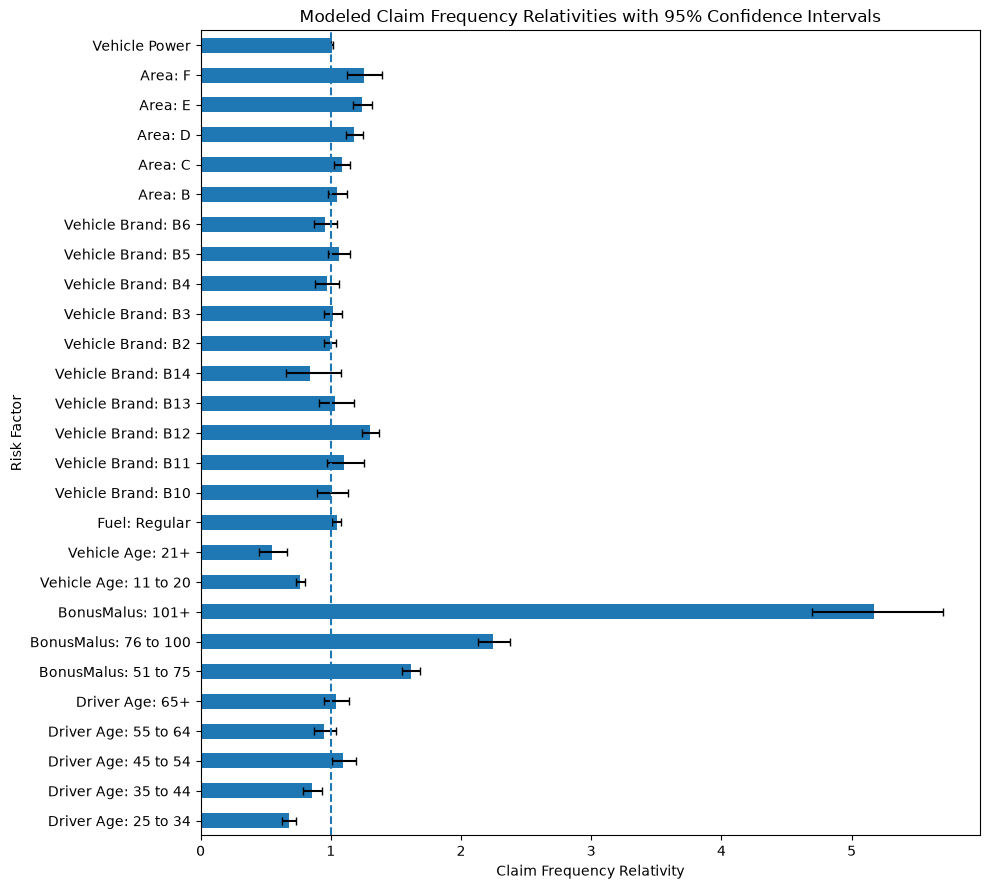

In [301]:
plot_results["Relativity"].plot(
    kind="barh",
    figsize=(10, 9),
    xerr=errors,
    capsize=3
)

plt.axvline(x=1, linestyle="--")
plt.xlabel("Claim Frequency Relativity")
plt.ylabel("Risk Factor")
plt.title("Modeled Claim Frequency Relativities with 95% Confidence Intervals")
plt.tight_layout()
plt.show()

### Claim Frequency Relativities

The figure presents modeled claim-frequency relativities with 95% confidence intervals from the Pearson-scaled Poisson GLM. The vertical dashed line at 1 represents the reference level of claim frequency.

BonusMalus shows the strongest modeled relationship with claim frequency. Relative to BonusMalus 50, the 51–75, 76–100, and 101+ categories have estimated relativities of approximately 1.61, 2.25, and 5.17, respectively. Vehicle age also shows a meaningful relationship, with older vehicles exhibiting lower modeled claim frequency relative to vehicles aged 0–10 years.

Confidence intervals that include 1 indicate insufficient statistical evidence of a difference from the corresponding reference category at the 5% significance level. Several vehicle-brand categories and some driver-age categories fall into this group.

These relativities represent associations after controlling for the other variables included in the model and should not be interpreted as causal effects.

### Train-Test Split

To evaluate the model's predictive performance on unseen observations, the dataset is randomly divided into training and test sets. The model is fitted using 80% of the policy records, while the remaining 20% are held out for out-of-sample evaluation. A fixed random seed is used to make the split reproducible.

In [302]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)
train_df.shape, test_df.shape

((542410, 15), (135603, 15))

In [303]:
train_model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.Poisson(),
    exposure=train_df["Exposure"]
)
train_result = train_model.fit(scale="X2")
train_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542382
Model Family:                 Poisson   Df Model:                           27
Link Function:                    Log   Scale:                          2.6688
Method:                          IRLS   Log-Likelihood:                -43025.
Date:                Sat, 05 Sep 2026   Deviance:                   1.7426e+05
Time:                        11:57:37   Pearson chi2:                 1.45e+06
No. Iterations:                     9   Pseudo R-squ. (CS):           0.003643
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.6868      0.064    -42.063      0.000      -2.812      -2.562
C(AgeCategory)[T.25 to 34]            -0.3880      0.046     -8.354      0.000      -0.479      -0.297
C(AgeCategory)[T.35 to 44]            -0.1468      0.048     -3.082      0.002      -0.240      -0.053
C(AgeCategory)[T.45 to 54]             0.1042      0.048      2.161      0.031       0.010       0.199
C(AgeCategory)[T.55 to 64]            -0.0465      0.052     -0.899      0.369      -0.148       0.055
C(AgeCategory)[T.65+]                  0.0593      0.053      1.124      0.261      -0.044       0.163
C(BonusMalusCategory)[T.51 to 75]      0.4692      0.025     18.610      0.000       0.420       0.519
C(BonusMalusCategory)[T.76 to 100]     0.8088      0.031     25.959      0.000       0.748       0.870
C(BonusMalusCategory)[T.101+]          1.6573      0.055     30.394      0.000       1.550       1.764
C(VehAgeCategory)[T.11 to 20]         -0.2680      0.024    -11.082      0.000      -0.315      -0.221
C(VehAgeCategory)[T.21+]              -0.5454      0.109     -4.996      0.000      -0.759      -0.331
C(VehGas)[T.Regular]                   0.0409      0.020      2.049      0.040       0.002       0.080
C(VehBrand)[T.B10]                    -0.0312      0.068     -0.457      0.648      -0.165       0.103
C(VehBrand)[T.B11]                     0.0504      0.074      0.682      0.495      -0.094       0.195
C(VehBrand)[T.B12]                     0.2693      0.029      9.277      0.000       0.212       0.326
C(VehBrand)[T.B13]                     0.0072      0.076      0.096      0.924      -0.141       0.155
C(VehBrand)[T.B14]                    -0.2292      0.148     -1.554      0.120      -0.518       0.060
C(VehBrand)[T.B2]                     -0.0057      0.028     -0.203      0.839      -0.060       0.049
C(VehBrand)[T.B3]                     -0.0133      0.040     -0.330      0.741      -0.092       0.065
C(VehBrand)[T.B4]                     -0.0344      0.054     -0.633      0.527      -0.141       0.072
C(VehBrand)[T.B5]                      0.0682      0.045      1.516      0.130      -0.020       0.156
C(VehBrand)[T.B6]                     -0.0510      0.052     -0.985      0.325      -0.153       0.051
C(Area)[T.B]                           0.0542      0.039      1.380      0.168      -0.023       0.131
C(Area)[T.C]                           0.0877      0.032      2.760      0.006       0.025       0.150
C(Area)[T.D]                           0.1703      0.033      5.171      0.000       0.106       0.235
C(Area)[T.E]                           0.2232      0.034      6.607      0.000       0.157       0.289
C(Area)[T.F]                           0.2310      0.061      3.758      0.000       0.111      

In [304]:
test_df["PredictedClaims"] = train_result.predict(
    test_df,
    exposure=test_df["Exposure"]
)
test_df[["ClaimNb", "Exposure", "PredictedClaims"]].head()

,ClaimNb,Exposure,PredictedClaims
261354,0,0.43,0.057508
448143,0,0.10,0.016341
188618,0,0.33,0.057812
12952,0,0.56,0.068487
425028,0,0.27,0.022603


In [305]:
test_df["ClaimNb"].sum()

np.int64(7241)

In [306]:
test_df["PredictedClaims"].sum()

np.float64(7195.206379978705)

In [307]:
prediction_error_pct = (
    (test_df["PredictedClaims"].sum() - test_df["ClaimNb"].sum())
    / test_df["ClaimNb"].sum()
) * 100

prediction_error_pct

np.float64(-0.6324212128337976)

In [308]:
age_test_validation = test_df.groupby(
    "AgeCategory",
    observed=True
).agg(
    ActualClaims=("ClaimNb", "sum"),
    PredictedClaims=("PredictedClaims", "sum"),
    Exposure=("Exposure", "sum")
)

age_test_validation

,ActualClaims,PredictedClaims,Exposure
AgeCategory,,,
18 to 24,479,457.967189,2472.907952
25 to 34,1325,1266.832557,12918.326617
35 to 44,1639,1607.922345,17364.618336
45 to 54,1884,1917.230950,18003.706744
55 to 64,1042,1019.770970,11270.144671
65+,872,925.482368,9594.718786


In [309]:
age_test_validation["ActualFrequency"] = (
    age_test_validation["ActualClaims"]
    / age_test_validation["Exposure"]
)

age_test_validation["PredictedFrequency"] = (
    age_test_validation["PredictedClaims"]
    / age_test_validation["Exposure"]
)

age_test_validation

,ActualClaims,PredictedClaims,Exposure,ActualFrequency,PredictedFrequency
AgeCategory,,,,,
18 to 24,479,457.967189,2472.907952,0.193699,0.185194
25 to 34,1325,1266.832557,12918.326617,0.102567,0.098065
35 to 44,1639,1607.922345,17364.618336,0.094387,0.092598
45 to 54,1884,1917.230950,18003.706744,0.104645,0.106491
55 to 64,1042,1019.770970,11270.144671,0.092457,0.090484
65+,872,925.482368,9594.718786,0.090883,0.096457


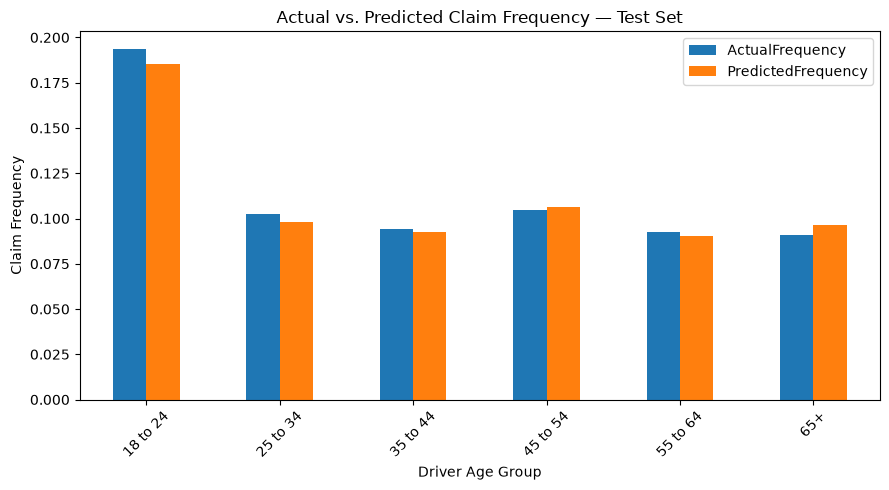

In [310]:
age_test_validation[
    ["ActualFrequency", "PredictedFrequency"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Driver Age Group")
plt.ylabel("Claim Frequency")
plt.title("Actual vs. Predicted Claim Frequency — Test Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Out-of-Sample Model Validation

The model was evaluated on a held-out test set containing 20% of the policy records. Overall, the model predicted approximately 7,195 claims compared with 7,241 actual claims, representing an aggregate underprediction of approximately 0.63%.

Actual and predicted claim frequencies are also reasonably close across driver-age groups. The model slightly underpredicts frequency for younger drivers and slightly overpredicts frequency for drivers aged 65+, while showing close agreement for the remaining age groups.

These results suggest that the model demonstrates reasonable out-of-sample calibration at both the overall portfolio level and across driver-age segments. Additional validation across predicted risk levels can provide a more complete assessment of model performance.

In [311]:
test_df["PredictedFrequency"] = (
    test_df["PredictedClaims"] / test_df["Exposure"]
)

test_df[["PredictedClaims", "Exposure", "PredictedFrequency"]].head()

,PredictedClaims,Exposure,PredictedFrequency
261354,0.057508,0.43,0.133738
448143,0.016341,0.10,0.163412
188618,0.057812,0.33,0.175189
12952,0.068487,0.56,0.122299
425028,0.022603,0.27,0.083714


In [312]:
test_df["RiskDecile"] = pd.qcut(
    test_df["PredictedFrequency"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1
test_df["RiskDecile"].value_counts().sort_index()

RiskDecile
1     13563
2     13558
3     13588
4     13570
5     13523
6     13564
7     13557
8     13562
9     13560
10    13558
Name: count, dtype: int64

In [313]:
risk_validation = test_df.groupby("RiskDecile").agg(
    ActualClaims=("ClaimNb", "sum"),
    PredictedClaims=("PredictedClaims", "sum"),
    Exposure=("Exposure", "sum")
)

risk_validation

,ActualClaims,PredictedClaims,Exposure
RiskDecile,,,
1,465,487.730779,9000.152634
2,541,579.646817,8692.277483
3,638,632.420167,8349.975795
4,702,681.251241,8180.847650
5,669,665.803375,7349.915027
6,661,677.815200,6825.724654
7,732,658.730279,5968.345727
8,766,742.423596,5936.809904
9,956,861.139333,5877.364783


In [314]:
risk_validation["ActualFrequency"] = (
    risk_validation["ActualClaims"]
    / risk_validation["Exposure"]
)

risk_validation["PredictedFrequency"] = (
    risk_validation["PredictedClaims"]
    / risk_validation["Exposure"]
)

risk_validation

,ActualClaims,PredictedClaims,Exposure,ActualFrequency,PredictedFrequency
RiskDecile,,,,,
1,465,487.730779,9000.152634,0.051666,0.054191
2,541,579.646817,8692.277483,0.062239,0.066685
3,638,632.420167,8349.975795,0.076407,0.075739
4,702,681.251241,8180.847650,0.085810,0.083274
5,669,665.803375,7349.915027,0.091021,0.090587
6,661,677.815200,6825.724654,0.096840,0.099303
7,732,658.730279,5968.345727,0.122647,0.110371
8,766,742.423596,5936.809904,0.129026,0.125054
9,956,861.139333,5877.364783,0.162658,0.146518


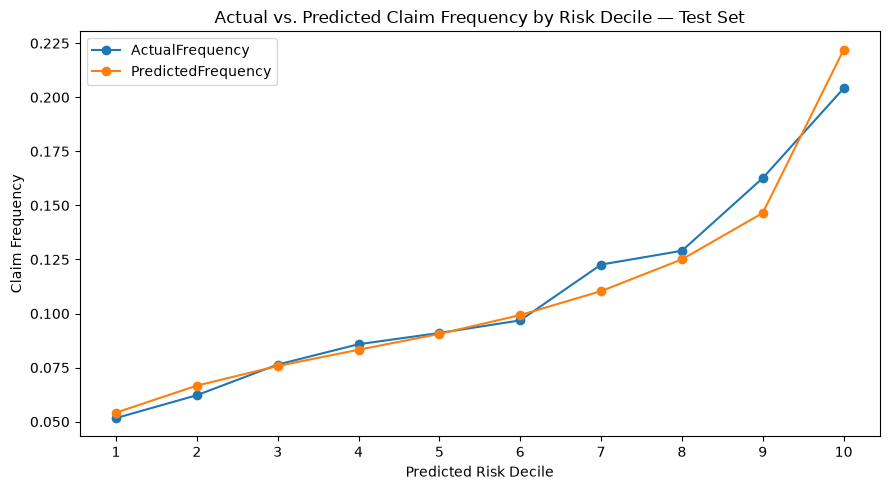

In [315]:
risk_validation[
    ["ActualFrequency", "PredictedFrequency"]
].plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.xlabel("Predicted Risk Decile")
plt.ylabel("Claim Frequency")
plt.title("Actual vs. Predicted Claim Frequency by Risk Decile — Test Set")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

### Risk-Decile Validation

To evaluate model performance across predicted risk levels, test-set records were divided into ten approximately equal-sized groups based on predicted claim frequency. Decile 1 represents the lowest predicted risk and Decile 10 represents the highest predicted risk.

Actual claim frequency generally increases across the predicted-risk deciles, from approximately 0.052 in Decile 1 to 0.204 in Decile 10. This indicates that the model is able to distinguish lower-risk from higher-risk policy records.

Predicted and actual frequencies are reasonably close across most deciles, although some differences remain, particularly in the higher-risk groups. Overall, the results indicate reasonable out-of-sample calibration and risk differentiation, while also showing that the model does not perfectly reproduce observed claim frequency within every risk segment.